# Dataset & DataLoader

In [1]:
import os
import random

import numpy as np

import torch
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T

from dataset_fixed import TrainDataset, TestDataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this script because the submission block uses .cuda().")

device = torch.device("cuda")

In [3]:
image_size = 64
batch_size_train = 64
batch_size_eval = 64

mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

val_ratio = 0.20
epochs = 15
label_smoothing = 0.1

save_path = "best_model.pth"

In [4]:
import numpy as np

def mixup_data(x, y, alpha=1.0, use_cuda=True):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    if use_cuda:
        index = torch.randperm(batch_size).cuda()
    else:
        index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [5]:
# data augmentation
train_transform = T.Compose([
    T.Pad(4, padding_mode='reflect'),
    T.RandomCrop(image_size),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(7),
    T.ColorJitter(brightness=0.02, contrast=0.02, saturation=0.02, hue=0.01),
    T.RandomGrayscale(p=0.02),
    T.ToTensor(),
    T.Normalize(mean, std),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

In [6]:
data_root = "./cs441-assn3-data"

train_dataset_aug  = TrainDataset(root_path=data_root, transform=train_transform)
train_dataset_eval = TrainDataset(root_path=data_root, transform=eval_transform)
test_dataset = TestDataset(root_path=data_root, transform=eval_transform)

In [7]:
def stratified_split(labels: np.ndarray, val_ratio: float, seed: int):
    """Return (train_indices, val_indices) with per-class stratification.
    No sklearn dependency.
    """
    rng = np.random.default_rng(seed)
    labels = labels.astype(int)
    classes, counts = np.unique(labels, return_counts=True)

    val_indices = []
    train_indices = []

    for c, cnt in zip(classes, counts):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        n_val_c = int(round(cnt * val_ratio))
        # keep at least 1 sample in train if possible
        n_val_c = min(max(n_val_c, 1), max(cnt - 1, 1))
        val_indices.extend(idx[:n_val_c].tolist())
        train_indices.extend(idx[n_val_c:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return train_indices, val_indices

In [8]:
labels = np.array(train_dataset_eval.labels, dtype=int)
train_indices, val_indices = stratified_split(labels, val_ratio=val_ratio, seed=SEED)

train_subset = Subset(train_dataset_aug, train_indices)
val_subset   = Subset(train_dataset_eval, val_indices)

num_workers = min(8, os.cpu_count() or 4)

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size_train,
    shuffle=True,
    num_workers=num_workers,
    drop_last=False,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size_eval,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size_eval,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

# Your Awesome Model

In [9]:
import torch
import torch.nn as nn

from custom_resnext import SEMXResNeXtFac

In [ ]:
model = SEMXResNeXtFac(classes=15)
model = model.to(device)

# Model parameter checking

In [11]:
# model parameters checking
num_params = sum(p.numel() for p in model.parameters())
print('The number of your model parameters :', num_params)
print('Parameter usage : ' + str(num_params/1000000) + '%')
if num_params > 100000000:
  raise Exception('Compress your model.')

The number of your model parameters : 15237327
Parameter usage : 15.237327%


# Model training

In [12]:
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim.lr_scheduler import SequentialLR, LambdaLR, CosineAnnealingLR

In [13]:
print("GPU count:", torch.cuda.device_count())
print("Current device index:", torch.cuda.current_device())
print("Current device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

GPU count: 1
Current device index: 0
Current device name: NVIDIA GeForce RTX 4080 SUPER


In [14]:
def mixup_batch(x, y, alpha: float):
    """Return mixed inputs and two targets for mixup CE."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

In [15]:
MAX_LR_STABLE = 1e-3 # 최대 LR (0.001)
BASE_LR_MIN = 5e-5   # 최소 LR (Max_LR의 약 1/20)
SGD_MAX_LR = 0.1
SGD_WD = 5e-4 # SGD는 WD를 낮게 씁니다.

# 1. 옵티마이저 설정 (최소 LR로 시작)
optimizer = optim.SGD(
    model.parameters(), 
    lr=BASE_LR_MIN,  # <-- OneCycleLR의 시작점 (최소 LR)
    momentum=0.9, 
    weight_decay=SGD_WD
)

# 2. 스케줄러 설정 (최대 LR로 점프)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=SGD_MAX_LR,  # <-- SGD의 목표 LR인 0.1로 변경
    epochs=epochs, 
    steps_per_epoch=len(train_loader),
    pct_start=0.3, 
    # div_factor는 Max_LR / Base_LR_Min 비율로 자동 계산
    div_factor=SGD_MAX_LR / BASE_LR_MIN, # 0.1 / 5e-5 = 2000
    final_div_factor=2000, 
)

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(device)
scaler = torch.amp.GradScaler("cuda")

'''
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

total_steps = epochs * len(train_loader)
warmup_steps = max(1, int(0.1 * total_steps))
T_max_cosine = max(1, total_steps - warmup_steps)

scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LambdaLR(optimizer, lambda step: (step + 1) / warmup_steps),
        CosineAnnealingLR(optimizer, T_max=T_max_cosine),
    ],
    milestones=[warmup_steps],
)
'''

best_val_acc = -1.0

In [34]:
print("Start Training...")

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for x, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step() 
        
        pred = out.argmax(dim=1)        
        train_loss_sum += loss.item() * x.size(0)
        train_correct += (pred == y).sum().item()
        train_total += x.size(0)

    # epochs 통계 출력
    train_loss = train_loss_sum / max(1, train_total)
    train_acc = train_correct / max(1, train_total)
    
    # VALIDATION
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = model(x)
            loss = criterion(out, y)

            val_loss_sum += loss.item() * y.size(0)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss_sum / max(1, val_total)
    val_acc = val_correct / max(1, val_total)
    
    # 한 줄로 깔끔하게 출력
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # Best Model 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  >>> Saved Best Model (Val Acc: {val_acc:.4f})")
    
    # 마지막 모델 저장
    torch.save(model.state_dict(), "last_model.pth")

Start Training...


Epoch 1/15 [Train]:   0%|          | 0/563 [00:00<?, ?it/s]c:\Users\user\miniconda3\envs\jupyter\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 01 | Train Loss: 5.1010 Acc: 0.1567 | Val Loss: 17.4771 Acc: 0.1493
  >>> Saved Best Model (Val Acc: 0.1493)


Epoch 02 | Train Loss: 3.1168 Acc: 0.2367 | Val Loss: 2.5782 Acc: 0.2923
  >>> Saved Best Model (Val Acc: 0.2923)


Epoch 03 | Train Loss: 2.2321 Acc: 0.3308 | Val Loss: 2.1211 Acc: 0.3742
  >>> Saved Best Model (Val Acc: 0.3742)


...

Epoch 11 | Train Loss: 1.5693 Acc: 0.5947 | Val Loss: 1.5416 Acc: 0.5999
  >>> Saved Best Model (Val Acc: 0.5999)


Epoch 12 | Train Loss: 1.4786 Acc: 0.6328 | Val Loss: 1.4803 Acc: 0.6247
  >>> Saved Best Model (Val Acc: 0.6247)


Epoch 13 | Train Loss: 1.3796 Acc: 0.6731 | Val Loss: 1.3867 Acc: 0.6637
  >>> Saved Best Model (Val Acc: 0.6637)


Epoch 14 | Train Loss: 1.2515 Acc: 0.7286 | Val Loss: 1.2796 Acc: 0.7149
  >>> Saved Best Model (Val Acc: 0.7149)


Epoch 15 | Train Loss: 1.1446 Acc: 0.7764 | Val Loss: 1.2511 Acc: 0.7289
  >>> Saved Best Model (Val Acc: 0.7289)


In [35]:
'''
print("Start Training Model...")

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    # TQDM에 'leave=False'를 주면 에폭마다 줄바꿈이 깔끔하게 됩니다.
    for x, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            # 만약 Loop 내부에서 CutMix를 적용한다면 여기서 x, y를 변환해야 함
            # x, y = cutmix_fn(x, y) 
            
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # 배치 단위 스케줄러 업데이트 (Correct)
        scheduler.step()

        # --- Stats ---
        # Mixup/CutMix 호환성 확보: y가 Soft Label일 경우 argmax로 변환
        pred = out.argmax(dim=1)
        if y.ndim > 1: 
            y_true = y.argmax(dim=1)
        else:
            y_true = y
            
        train_loss_sum += loss.item() * y.size(0)
        train_correct += (pred == y_true).sum().item()
        train_total += y.size(0)

    # 에폭 통계 출력
    train_loss = train_loss_sum / max(1, train_total)
    train_acc = train_correct / max(1, train_total)
    
    # --- VALIDATION ---
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = model(x)
            loss = criterion(out, y)

            val_loss_sum += loss.item() * y.size(0)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss_sum / max(1, val_total)
    val_acc = val_correct / max(1, val_total)
    
    # 한 줄로 깔끔하게 출력
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Best Model 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  >>> Saved Best Model (Val Acc: {val_acc:.4f})")
    
    # (선택) 마지막 모델 저장
    torch.save(model.state_dict(), "last_model.pth")
'''

'\nprint("Start Training Model...")\n\nfor epoch in range(epochs):\n    # --- TRAIN ---\n    model.train()\n    train_loss_sum = 0.0\n    train_correct = 0\n    train_total = 0\n\n    # TQDM에 \'leave=False\'를 주면 에폭마다 줄바꿈이 깔끔하게 됩니다.\n    for x, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):\n        x = x.to(device, non_blocking=True)\n        y = y.to(device, non_blocking=True)\n\n        optimizer.zero_grad(set_to_none=True)\n\n        with torch.amp.autocast("cuda"):\n            # 만약 Loop 내부에서 CutMix를 적용한다면 여기서 x, y를 변환해야 함\n            # x, y = cutmix_fn(x, y) \n            \n            out = model(x)\n            loss = criterion(out, y)\n\n        scaler.scale(loss).backward()\n        scaler.step(optimizer)\n        scaler.update()\n        \n        # 배치 단위 스케줄러 업데이트 (Correct)\n        scheduler.step()\n\n        # --- Stats ---\n        # Mixup/CutMix 호환성 확보: y가 Soft Label일 경우 argmax로 변환\n        pred = out.argmax(dim=1)\n        if y.ndi

In [16]:
model.load_state_dict(torch.load(save_path, map_location=device))

C:\Users\user\AppData\Local\Temp\ipykernel_16464\1058478286.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=devi

<All keys matched successfully>

Step 1: Extracting Training Features...
Extracting features from loader...


Step 2: Extracting Validation Features & Logits...
Extracting features from loader...


Feature Shape: (36000, 1024)

[Softmax Classifier] Validation Accuracy: 0.7291

Step 3: Training Linear SVM on extracted features...


c:\Users\user\miniconda3\envs\jupyter\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[SVM Classifier]     Validation Accuracy: 0.7197

Final Comparison:
Softmax Acc: 0.7291
SVM Acc:     0.7197
👉 기존 Softmax가 더 좋습니다. 모델 구조나 학습 방식을 개선하는 게 낫습니다.


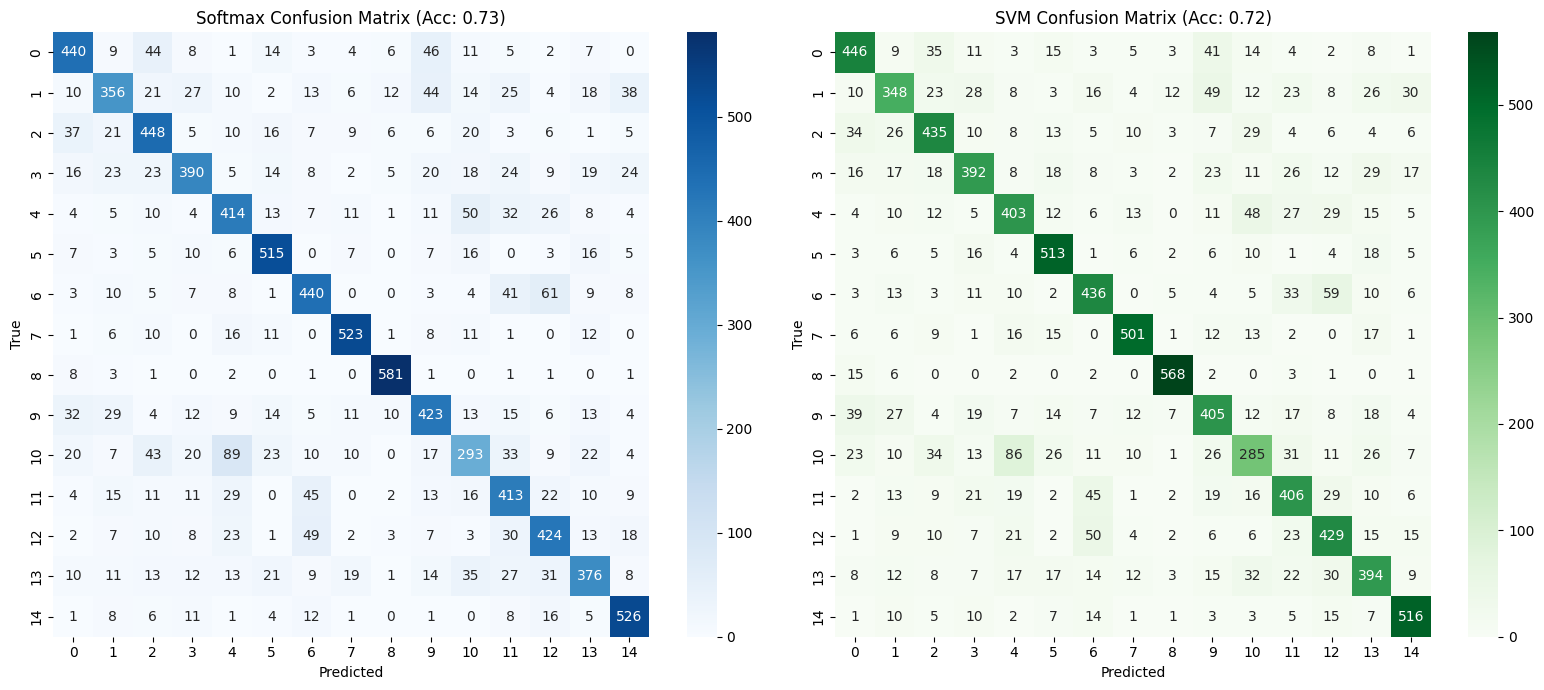


Classification Report (Softmax):
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       600
           1       0.69      0.59      0.64       600
           2       0.69      0.75      0.71       600
           3       0.74      0.65      0.69       600
           4       0.65      0.69      0.67       600
           5       0.79      0.86      0.82       600
           6       0.72      0.73      0.73       600
           7       0.86      0.87      0.87       600
           8       0.93      0.97      0.95       600
           9       0.68      0.70      0.69       600
          10       0.58      0.49      0.53       600
          11       0.63      0.69      0.66       600
          12       0.68      0.71      0.70       600
          13       0.71      0.63      0.67       600
          14       0.80      0.88      0.84       600

    accuracy                           0.73      9000
   macro avg       0.73      0.73      0.73   

In [19]:
import torch
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

def get_features_and_logits(model, loader, device):
    """
    모델로부터 Feature Vector(SVM용)와 Logits(Softmax용)을 추출합니다.
    """
    model.eval()
    features_list = []
    logits_list = []
    labels_list = []
    
    # Hook을 사용하여 Classifier 직전의 Feature Vector를 가로챕니다.
    # SEMXResNeXt 구조상 model.classifier의 입력(input[0])이 Feature입니다.
    def hook_fn(module, input, output):
        # input은 튜플 형태이므로 첫 번째 요소를 가져옵니다.
        # CPU로 옮겨서 리스트에 저장 (메모리 절약)
        features_list.append(input[0].detach().cpu().numpy())

    # Classifier 레이어에 Hook 등록
    handle = model.classifier.register_forward_hook(hook_fn)

    print(f"Extracting features from loader...")
    with torch.no_grad():
        for x, y in tqdm.tqdm(loader, leave=False):
            x = x.to(device)
            # 모델을 통과시키면 Logit은 반환되고, Hook이 Feature를 캡처함
            out = model(x)
            
            logits_list.append(out.detach().cpu().numpy())
            labels_list.append(y.detach().cpu().numpy())
            
    # Hook 제거
    handle.remove()
    
    # 리스트를 하나의 거대한 Numpy 배열로 병합
    features = np.concatenate(features_list, axis=0)
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    return features, logits, labels

# ==========================================
# 1. 데이터 추출 (Train & Validation)
# ==========================================
# SVM을 학습시키려면 Train 데이터의 Feature가 필요합니다.
print("Step 1: Extracting Training Features...")
X_train, _, y_train = get_features_and_logits(model, train_loader, device)

print("Step 2: Extracting Validation Features & Logits...")
X_val, val_logits, y_val = get_features_and_logits(model, val_loader, device)

print(f"Feature Shape: {X_train.shape}") # 예: (45000, 1024) 등

# ==========================================
# 2. Softmax (기존 방식) 성능 평가
# ==========================================
# Logits에서 가장 큰 값을 가진 인덱스가 예측값
val_preds_softmax = np.argmax(val_logits, axis=1)
acc_softmax = accuracy_score(y_val, val_preds_softmax)

print(f"\n[Softmax Classifier] Validation Accuracy: {acc_softmax:.4f}")

# ==========================================
# 3. SVM (Metric Learning 방식) 성능 평가
# ==========================================
print("\nStep 3: Training Linear SVM on extracted features...")

# SVM은 데이터 스케일에 민감하므로 정규화 권장 (딥러닝 특징은 보통 괜찮지만 안전하게)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# LinearSVM 사용 (RBF 커널은 데이터가 많으면 너무 느림)
# C값은 규제 강도. 기본 1.0. (조정 가능)
svm_clf = LinearSVC(C=1.0, max_iter=1000, verbose=0)
svm_clf.fit(X_train_scaled, y_train)

# 예측
val_preds_svm = svm_clf.predict(X_val_scaled)
acc_svm = accuracy_score(y_val, val_preds_svm)

print(f"[SVM Classifier]     Validation Accuracy: {acc_svm:.4f}")

# ==========================================
# 4. 결과 비교 및 혼동 행렬 시각화
# ==========================================
print("\n" + "="*50)
print(f"Final Comparison:")
print(f"Softmax Acc: {acc_softmax:.4f}")
print(f"SVM Acc:     {acc_svm:.4f}")
print("="*50)

if acc_svm > acc_softmax + 0.01:
    print("👉 SVM이 Softmax보다 유의미하게(>1%) 더 좋습니다. SVM 도입을 고려하세요.")
elif acc_softmax > acc_svm:
    print("👉 기존 Softmax가 더 좋습니다. 모델 구조나 학습 방식을 개선하는 게 낫습니다.")
else:
    print("👉 성능 차이가 미미합니다. 배포 편의성을 위해 Softmax 유지를 추천합니다.")

# 혼동 행렬 시각화 (어디서 틀리는지 비교)
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Softmax Confusion Matrix
cm_softmax = confusion_matrix(y_val, val_preds_softmax)
sns.heatmap(cm_softmax, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Softmax Confusion Matrix (Acc: {acc_softmax:.2f})')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_val, val_preds_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f'SVM Confusion Matrix (Acc: {acc_svm:.2f})')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# 상세 리포트 출력 (Softmax 기준)
print("\nClassification Report (Softmax):")
print(classification_report(y_val, val_preds_softmax))

# Submit
Do not edit the submission code below.

In [20]:
import pandas as pd

# Load Best Model
submit = pd.read_csv('./cs441-assn3-data/Test_64.csv')

# model parameters checking
num_params = sum(p.numel() for p in model.parameters())
print('The number of your model parameters :', num_params)
print('Parameter usage : ' + str(num_params/1000000) + '%')
if num_params > 100000000:
  raise Exception('Compress your model.')

total_prediction = list()
model.eval()
with torch.no_grad():
    for x in tqdm.tqdm(test_loader):
        x = torch.FloatTensor(x).cuda()
        output = model(x)
        predict = torch.argmax(output,dim=1)
        total_prediction.extend(predict.cpu().numpy())
    submit['label'] = total_prediction
    submit.to_csv('submission.csv',index=False)

The number of your model parameters : 15237327
Parameter usage : 15.237327%


100%|██████████| 118/118 [00:26<00:00,  4.39it/s]
